
# Bayesian Hierarchical ARX Hurdle Model for Gravity Migration


**A. Hurdle (Bernoulli)** : 
$\text{logit}(P(\text{flow}>0)) = \alpha_d + X_h \beta_h + \beta_{lag} \text{is\_mig\_lag}$

**B. Volume (ARX)** : 
$$\log(\text{flow}) \sim \mathcal{N}(\mu_{d,t} + \phi_d (\text{lag} - \mu_{d,t-1}), \sigma_d)$$
$$\mu_{d,t} = \alpha_{V,d} + X \beta_{\text{grav}} + \beta_{\text{gdp}} \log(\text{gdpcap\_o}) + \beta_{\text{rich}} \text{is\_rich\_o}$$

**C. Variance (Geo)** : 
$\sigma_d \sim \text{HalfNormal}(\sigma_{\text{cluster}}[\text{continent\_origine}[d]])$ *(alternative à InverseGamma)*


# MÉTHODOLOGIE 
*(pour rapport ou annexe)*

1) Couplage entre bayésien & Machine Learning (Partie ARX et Variance Géo).  
Ce modèle bayésien intègre les découvertes faites par le Random Forest :
- Saut brutal de migration autour de 18 000 $ de PIB/hab. 
  Encodé par la variable indicatrice 'is_rich_o' 
- Interaction 'log_D_ij * LB_ij' (distance * frontière commune) 
  dont l'importance a été découverte par un PDP 2D du Random forest, et prouvée par régression linéaire 
- Correction des résidus : La cartographie des erreurs des XGBoost & RF montrait une incertitude 
  systématique (sous/sur-estimation) en Afrique, et un peu en Asie/Amerique latine. L'hétéroscédasticité 
  géographique modélise cette variance propre à chaque continent (à affiner par zone géo plus précise?)


2) Gestion des zéros (partie Hurdle). 
Le problème: il y a beaucoup de flux nuls, et on ne peut ni les enlever de l'analyse, ni faire log(x+1) (scientifiquement mauvais)
Forcer un pic à zéro pour loi Normale (qui ne sait faire que une cloche, et pas une cloche + un pic à zéro) fait diverger 
la variance et les chaines de Markov. 
Le modèle Hurdle: regression logistique (Bernoulli); si et seulement si le couloir est ouvert (>0) => équation de gravité ARX. 
Si non (flux=0) STAN s'arrête là et prédit 0 migrant (dans la phase de prédiction)



3) intuition physique de STAN (Hamiltonian Monte Carlo). 
Contrairement aux auteurs qui utilisaient le Gibbs sampling via JAGS, Stan utilise HMC. 
 HMC utilise la mécanique hamiltonienne pour explorer le paysage des posteriors bayésiens, (trajectoire guidée par lmes équations de Hamilton)
avec une étape d'acceptation Metropolis-Hastings à la fin selon $$P(\text{acceptation}) = \min(1, \exp(-\Delta H))$$ 
pour corriger les erreurs numériques sur la conservation de l'énergie ($$\Delta H =0$$) liées à la discrétisation de temporelle. 


Une exploration entière par Metropolis (marche aléatoire) aurait été inefficace et incroyablement lente pour autant de paramètres

4) Stabilité géométrique.  
Pour éviter que l'algorithme ne se coince (entonnoir), au lieu d'échantillonner 
directement α_d ~ N(μ, τ), on échantillonne un bruit pur ε ~ N(0,1), puis on calcule 
 α_d = μ + τ·ε. Cela détruit les corrélations pathologiques durant le HMC 

5) Approche dyadique.  
Mon modèle est purement "Dyadique" contrairement à celui de Ishagh (Inflow/Outflow). Ce code modélise chaque couloir de migration.  
On pourra comparer les deux approches in fine. 

6) Évaluation Out-Of-Sample.  
Le modèle est entraîné sur la période 1990-2010 et testé en prédiction pure sur 2015. 
Pour évaluer la qualité de la prédiction, on retient la MAE (Erreur absolue en nombre d'humains réels) et le WMAPE 
(Weighted Mean Absolute Percentage Error), qui pondére l'erreur par la taille du 
flux pour éviter l'explosion mathématique des pourcentages sur les couloirs proches de zéro.


In [1]:
# Installation des bibliothèques non classiqus
# !pip install pycountry_convert arviz cmdstanpy

# compilation de Stan
# import cmdstanpy
# cmdstanpy.install_cmdstan()

In [ ]:

import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import pycountry_convert as pc
from cmdstanpy import CmdStanModel
from sklearn.metrics import accuracy_score

warnings.filterwarnings('ignore')
np.random.seed(42)




# Chargement & filtrage pays




DATA_PATH = "../data/data_final/DF_GRAVITY_sans_NaN.csv"
df_main = pd.read_csv(DATA_PATH)


# Tous les pays
  
df = df_main[df_main['orig'] != df_main['dest']].copy()
df = df.sort_values(['orig', 'dest', 'year']).reset_index(drop=True)
print(f"Lignes chargées : {len(df)} | Pays uniques : {df['orig'].nunique()}")


"""
#  Décommenter pour sanity-check ou simulation plus globale 




# 32 pays 
PAYS_NORD    = ['FRA', 'USA', 'ESP', 'CAN', 'DEU', 'GBR', 'ITA', 'AUS', 'CHE']
PAYS_AFRIQUE = ['DZA', 'RWA', 'ZAF', 'NER', 'NGA', 'COD', 'SOM', 'MAR', 'EGY']
PAYS_AMLAT   = ['HTI', 'MEX', 'VEN', 'COL', 'BRA', 'SLV']
PAYS_ASIE    = ['MMR', 'IND', 'CHN', 'SYR', 'AFG', 'PAK', 'PHL', 'BGD']
"""

"""
# 66 pays (production)
PAYS_NORD    = ['FRA', 'USA', 'ESP', 'CAN', 'DEU', 'GBR', 'ITA', 'AUS', 'CHE',
                'JPN', 'KOR', 'NLD', 'SWE', 'BEL', 'AUT', 'POL', 'NZL']
PAYS_AFRIQUE = ['DZA', 'RWA', 'ZAF', 'NER', 'NGA', 'COD', 'SOM', 'MAR', 'EGY',
               'SEN', 'CIV', 'KEN', 'ETH', 'GHA', 'AGO', 'TUN', 'CMR']
PAYS_AMLAT   = ['HTI', 'MEX', 'VEN', 'COL', 'BRA', 'SLV',
                'ARG', 'CHL', 'PER', 'ECU', 'CUB', 'DOM', 'GTM', 'BOL', 'URY']
PAYS_ASIE    = ['MMR', 'IND', 'CHN', 'SYR', 'AFG', 'PAK', 'PHL', 'BGD',
                 'VNM', 'THA', 'IDN', 'MYS', 'IRN', 'SAU', 'TUR', 'IRQ', 'ARE']
"""

# PAYS_TEST = PAYS_NORD + PAYS_AFRIQUE + PAYS_AMLAT + PAYS_ASIE

"""

df = df_main[
    df_main['orig'].isin(PAYS_TEST) &
    df_main['dest'].isin(PAYS_TEST) &
    (df_main['orig'] != df_main['dest'])
].copy()
df = df.sort_values(['orig', 'dest', 'year']).reset_index(drop=True)

"""


/opt/anaconda3/envs/datasci/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


Lignes chargées : 185578 | Pays uniques : 190


"\ndf = df_main[\n    df_main['orig'].isin(PAYS_TEST) &\n    df_main['dest'].isin(PAYS_TEST) &\n    (df_main['orig'] != df_main['dest'])\n].copy()\ndf = df.sort_values(['orig', 'dest', 'year']).reset_index(drop=True)\n"

In [3]:
# Clustering géographique




def get_continent_id(iso3_code):
    try:
        iso2 = pc.country_alpha3_to_country_alpha2(iso3_code)
        continent = pc.country_alpha2_to_continent_code(iso2)
        return {'EU': 1, 'NA': 2, 'AF': 3, 'SA': 4, 'AS': 5, 'OC': 6}.get(continent, 7)
    except Exception:
        return 7

df['continent_orig'] = df['orig'].apply(get_continent_id)
K_clusters = 6




In [4]:
# Features, lags et split train/test




df['is_migration'] = (df['flow'] > 0).astype(int)
df['log_flow']     = np.where(df['flow'] > 0, np.log(df['flow']), np.nan)

SEUIL_LOG_GDP       = 2.9
df['is_rich_o']     = (df['log_gdpcap_o_lag'] > SEUIL_LOG_GDP).astype(float)

df['log_D_ij']      = np.log(df['D_ij'].replace(0, np.nan))
df['logD_times_LB'] = df['log_D_ij'] * df['LB_ij']

df['dyad']          = df['orig'] + "_" + df['dest']
df['is_mig_lag']    = df.groupby('dyad')['is_migration'].shift(1)
df['log_flow_lag']  = df.groupby('dyad')['log_flow'].shift(1)
df = df.dropna(subset=['is_mig_lag']).reset_index(drop=True)

HURDLE_VARS     = ['log_D_ij', 'LB_ij', 'logD_times_LB']
ML_VARS         = ['log_gdpcap_o_lag', 'is_rich_o']
GRAVITY_VARS_RAW = ['P_it', 'P_jt', 'PSR_i', 'PSR_j', 'IMR_it', 'IMR_jt',
                    'urban_it', 'urban_jt', 'LA_i', 'LA_j']
GRAVITY_VARS_BIN = ['LL_i', 'LL_j', 'LB_ij', 'OL_ij', 'COL_ij',
                    't_2000', 't_2000_sq', 'log_gdpcap_d_lag']

for raw in GRAVITY_VARS_RAW:
    df[f'log_{raw}'] = np.log(df[raw].replace(0, np.nan))

X_VOL_COLS = [f'log_{v}' for v in GRAVITY_VARS_RAW] + GRAVITY_VARS_BIN + ML_VARS
K_grav, K_h = len(X_VOL_COLS), len(HURDLE_VARS)

df_train = df[df['year'] <= 2010].copy()
df_test  = df[df['year'] == 2015].copy()
df       = df_train  




In [5]:
# Séparation hurdle / volume




HURDLE_REQUIRED = HURDLE_VARS + ['is_mig_lag', 'is_migration', 'dyad', 'continent_orig']
df_hurdle = df.dropna(subset=HURDLE_REQUIRED).copy().reset_index(drop=True)

VOLUME_REQUIRED = X_VOL_COLS + ['log_flow', 'log_flow_lag', 'dyad', 'continent_orig']
df_volume = df[df['flow'] > 0].dropna(subset=VOLUME_REQUIRED).copy().reset_index(drop=True)

N_h, N_v = len(df_hurdle), len(df_volume)



In [6]:

# avant Stan Data 

# Centrage de log_flow autour de la moyenne train
log_flow_mean = df_volume['log_flow'].mean()
log_flow_std  = df_volume['log_flow'].std()

print(f"log_flow mean={log_flow_mean:.3f}, std={log_flow_std:.3f}")

# Centrage (pas réduction : on garde l'échelle pour l'interprétation)
df_volume['log_flow_centered']     = df_volume['log_flow']     - log_flow_mean
df_volume['log_flow_lag_centered'] = df_volume['log_flow_lag'] - log_flow_mean

# Idem pour le test — centré sur la moyenne des LAGS train (pas log_flow)
log_flow_lag_mean = df_volume['log_flow_lag'].mean()

df_test['log_flow_lag_centered'] = (
    df_test['log_flow_lag']
    .fillna(0.0)
    .sub(log_flow_lag_mean)
    .replace([np.inf, -np.inf], 0.0)
    .clip(-20, 20)
)

print(f"log_flow_lag_mean train : {log_flow_lag_mean:.3f}")
print(f"log_flow_lag_centered test mean : {df_test['log_flow_lag_centered'].mean():.4f}")

log_flow mean=4.539, std=2.907
log_flow_lag_mean train : 4.415
log_flow_lag_centered test mean : -2.1487


In [7]:

# Encodage dyades et standardisation




dyades_h  = sorted(df_hurdle['dyad'].unique())
dyad_to_h = {d: i+1 for i, d in enumerate(dyades_h)}
df_hurdle['dyad_id_h'] = df_hurdle['dyad'].map(dyad_to_h)
D_h = len(dyades_h)
cluster_h = (df_hurdle.groupby('dyad')['continent_orig'].first()
             .reindex([k for k, v in sorted(dyad_to_h.items(), key=lambda x: x[1])])
             .values.astype(int))

dyades_v  = sorted(df_volume['dyad'].unique())
dyad_to_v = {d: i+1 for i, d in enumerate(dyades_v)}
df_volume['dyad_id_v'] = df_volume['dyad'].map(dyad_to_v)
D_v = len(dyades_v)
cluster_v = (df_volume.groupby('dyad')['continent_orig'].first()
             .reindex([k for k, v in sorted(dyad_to_v.items(), key=lambda x: x[1])])
             .values.astype(int))

BINARY_COLS_VOL = ['LL_i', 'LL_j', 'LB_ij', 'OL_ij', 'COL_ij', 'is_rich_o']
BINARY_COLS_HUR = ['LB_ij']

def standardize_matrix(X, col_names, binary_cols, fit_stats=None):
    X_std, stats = X.copy().astype(float), {}
    for j, col in enumerate(col_names):
        if col not in binary_cols:
            mu = X[:, j].mean() if fit_stats is None else fit_stats[col]['mean']
            sd = X[:, j].std()  if fit_stats is None else fit_stats[col]['std']
            sd = max(sd, 1e-8)
            X_std[:, j] = (X[:, j] - mu) / sd
            stats[col] = {'mean': mu, 'std': sd}
        else:
            stats[col] = {'mean': 0.0, 'std': 1.0}
    return X_std, stats

X_vol_std, stats_vol = standardize_matrix(df_volume[X_VOL_COLS].values, X_VOL_COLS, BINARY_COLS_VOL)
X_h_std,   stats_h   = standardize_matrix(df_hurdle[HURDLE_VARS].values, HURDLE_VARS, BINARY_COLS_HUR)



In [8]:


# Préparation du jeu de test OOS




df_test['dyad']          = df_test['orig'] + "_" + df_test['dest']
df_test['dyad_id_test']  = df_test['dyad'].map(dyad_to_h)
df_test['dyad_id_test_v']= df_test['dyad'].map(dyad_to_v).fillna(0).astype(int)

df_test = df_test.dropna(subset=['dyad_id_test']).copy().reset_index(drop=True)

df_test['continent_orig_fill'] = df_test['orig'].apply(get_continent_id)
df_test['continent_orig_fill'] = df_test['continent_orig_fill'].fillna(7).astype(int)
cluster_test_h = df_test['continent_orig_fill'].values.astype(int)

log_flow_lag_test = df_test['log_flow_lag'].fillna(0.0).values
is_mig_lag_test   = df_test['is_mig_lag'].fillna(0.0).values

X_test_v_std, _ = standardize_matrix(df_test[X_VOL_COLS].values, X_VOL_COLS,
                                     BINARY_COLS_VOL, fit_stats=stats_vol)
X_test_h_std, _ = standardize_matrix(df_test[HURDLE_VARS].values, HURDLE_VARS,
                                     BINARY_COLS_HUR, fit_stats=stats_h)


In [ ]:




# Construction du dictionnaire Stan




stan_data = {
    'N_h'        : int(N_h),
    'D_h'        : int(D_h),
    'K_h'        : int(K_h),
    'dyad_id_h'  : df_hurdle['dyad_id_h'].astype(int).tolist(),
    'is_mig'     : df_hurdle['is_migration'].astype(int).tolist(),
    'is_mig_lag' : df_hurdle['is_mig_lag'].astype(float).tolist(),
    'X_h'        : X_h_std.tolist(),
    'cluster_h'  : cluster_h.tolist(),

    'N_v'          : int(N_v),
    'D_v'          : int(D_v),
    'K_v'          : int(K_grav),
    'dyad_id_v'    : df_volume['dyad_id_v'].astype(int).tolist(),
    'log_flow'     : df_volume['log_flow_centered'].astype(float).tolist(),
    'log_flow_lag' : df_volume['log_flow_lag_centered'].astype(float).tolist(),
    'X_v'          : X_vol_std.tolist(),
    'cluster_v'    : cluster_v.tolist(),

    'K_clusters'   : int(K_clusters),

    'do_ppc': 0,

    'N_test'            : int(len(df_test)),
    'dyad_id_test_h'    : df_test['dyad_id_test'].astype(int).tolist(),
    'dyad_id_test_v'    : df_test['dyad_id_test_v'].astype(int).tolist(),
    'X_h_test'          : X_test_h_std.tolist(),
    'is_mig_lag_test'   : is_mig_lag_test.tolist(),
    'X_v_test'          : X_test_v_std.tolist(),
    'log_flow_lag_test' : df_test['log_flow_lag_centered'].tolist(),
    'cluster_test_h'    : cluster_test_h.tolist(),
    
}


In [ ]:


# Sampling Stan




STAN_FILE = "../STAN/HMC_ARX_v4.stan" 

import os

# Supprime le binaire en cache
binary = STAN_FILE.replace('.stan', '')
if os.path.exists(binary):
    os.remove(binary)
    print(f"Binaire supprimé : {binary}")

# recompilation forcée automatiquement
model = CmdStanModel(stan_file=STAN_FILE)

fit = model.sample(
    data             = stan_data,
    chains           = 2,
    parallel_chains  = 2,       
    iter_warmup      = 200,
    iter_sampling    = 200,
    save_warmup      = False,
    seed             = 42,
    thin             = 10,       
    adapt_delta      = 0.98,
    max_treedepth    = 12,
    show_progress    = True,
)

print(fit.summary().loc[[
    'alpha_global', 'tau_alpha', 'beta_lag_global',
    'mu_intercept', 'tau_mu', 'phi_global_monitor'
]])




14:15:24 - cmdstanpy - INFO - compiling stan file /var/folders/47/r5kv9z4j6kg1sk0dvr2l5ydh0000gn/T/tmp_p4pik4_/tmpiprnj1js.stan to exe file /Users/romain/Desktop/Projets DS/ProjetStat/STAN/HMC_ARX_v3


Binaire supprimé : ../STAN/HMC_ARX_v3


14:15:41 - cmdstanpy - INFO - compiled model executable: /Users/romain/Desktop/Projets DS/ProjetStat/STAN/HMC_ARX_v3
14:15:45 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/100 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/100 [00:00<?, ?it/s, (Warmup)]

14:25:21 - cmdstanpy - ERROR - Chain [1] error: code '-2' Unknown error: -2
14:25:21 - cmdstanpy - ERROR - Chain [2] error: code '-2' Unknown error: -2


KeyboardInterrupt: 

In [ ]:

# Chargement ArviZ optimisé RAM-efficient




idata = az.from_cmdstanpy(
    posterior = fit,
    log_likelihood = {
        'hurdle' : 'log_lik_h',
        'volume' : 'log_lik_v',
    },
    posterior_predictive = {
        'is_mig_hat'      : 'is_mig_hat',       
        'flow_hat_jensen' : 'flow_hat_jensen',  
    },
)

print(az.summary(idata, var_names=[
    'alpha_global', 'tau_alpha', 'beta_lag_global',
    'mu_intercept', 'phi_global_monitor', 'sigma_global'
]))

                     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
alpha_global       -2.369  0.179  -2.716   -2.037      0.005    0.004   
tau_alpha           0.137  0.104   0.000    0.321      0.003    0.002   
beta_lag_global     6.663  0.228   6.254    7.108      0.006    0.004   
mu_intercept        2.362  0.495   1.532    3.369      0.013    0.010   
phi_global_monitor  0.946  0.007   0.932    0.957      0.000    0.000   
sigma_global        0.579  0.203   0.189    0.948      0.005    0.004   

                    ess_bulk  ess_tail  r_hat  
alpha_global          1445.0    1501.0    1.0  
tau_alpha             1443.0    1350.0    1.0  
beta_lag_global       1480.0    1461.0    1.0  
mu_intercept          1525.0    1387.0    1.0  
phi_global_monitor    1427.0    1496.0    1.0  
sigma_global          1380.0    1344.0    1.0  


In [ ]:


# Prédictions OOS en NumPy (Jensen-corrigé, RAM-efficient)




prob_mig = fit.stan_variable('prob_mig_test')   
mu_test  = fit.stan_variable('mu_dt_test')       
sigma_t  = fit.stan_variable('sigma_test')       


sigma_t_clipped  = np.clip(sigma_t,  0,   2.0)
mu_test_clipped  = np.clip(mu_test, -5,  25.0)
flow_cond_draws  = np.exp(mu_test_clipped + 0.5 * np.square(sigma_t_clipped))

mu_test_decentered = mu_test_clipped + log_flow_mean
flow_cond_draws = np.exp(mu_test_decentered + 0.5 * np.square(sigma_t_clipped))

prob_med      = np.median(prob_mig,        axis=0)  
flow_cond_med = np.median(flow_cond_draws, axis=0)  
y_pred        = prob_med * flow_cond_med             

flow_all  = prob_mig * flow_cond_draws               
y_pred_q05 = np.percentile(flow_all, 5,  axis=0)
y_pred_q95 = np.percentile(flow_all, 95, axis=0)

print(f"Prédictions OOS reconstruites : {y_pred.shape[0]} observations")
print(f"  Médiane prédite : {np.median(y_pred):,.0f} migrants")
print(f"  Max prédit      : {y_pred.max():,.0f} migrants")

Prédictions OOS reconstruites : 756 observations
  Médiane prédite : 3,210 migrants
  Max prédit      : 2,706,320 migrants


In [ ]:
# Métriques OOS




y_true = df_test['flow'].values

y_true_bin = (y_true > 0).astype(int)
y_pred_bin = (y_pred > 0.5).astype(int)
acc = accuracy_score(y_true_bin, y_pred_bin)
print(f"Hurdle Accuracy (open/close) : {acc*100:.1f}%")

mask = y_true > 0
cond_mae = np.mean(np.abs(y_true[mask] - y_pred[mask]))
print(f"Conditional MAE (flow > 0)   : {cond_mae:,.0f} migrants")

global_mae  = np.mean(np.abs(y_true - y_pred))
wmape       = np.sum(np.abs(y_true - y_pred)) / (np.sum(y_true) + 1e-8) * 100
log_mae     = np.mean(np.abs(np.log1p(y_true) - np.log1p(y_pred)))
coverage    = np.mean((y_true >= y_pred_q05) & (y_true <= y_pred_q95))

print(f"\nGlobal MAE            : {global_mae:,.0f} migrants")
print(f"Global WMAPE          : {wmape:.1f}%   ← métrique principale")
print(f"Log-MAE               : {log_mae:.4f}  ← comparable aux modèles ML")
print(f"IC 90% Coverage       : {coverage*100:.1f}%  (cible ~90%)")

print(f"\n--- Benchmarks ---")
print(f"  {'Welch & Raftery (bayésien hiér.)':<35} Log-MAE ~0.35") # à verifier, et calculer MAE
print(f"  {'XGBoost (notre résultat, flow>0)':<35} MAE ~1949 migrants") # à verifier, et calculer log-MAE
print(f"  {'Random Forest (notre résultat, flow>0)':<35} MAE ~1472 migrants") # à verifier, et calculer log-MAE
print(f"  {'ARX Hurdle Bayésien (ce modèle)':<35} Log-MAE {log_mae:.3f}")





Hurdle Accuracy (open/close) : 81.7%
Conditional MAE (flow > 0)   : 29,924 migrants

Global MAE            : 24,581 migrants
Global WMAPE          : 79.7%   ← métrique principale
Log-MAE               : 1.5370  ← comparable aux modèles ML
IC 90% Coverage       : 17.2%  (cible ~90%)

--- Benchmarks ---
  Welch & Raftery (bayésien hiér.)    Log-MAE ~0.35
  XGBoost (notre résultat, flow>0)    MAE ~1949 migrants
  Random Forest (notre résultat, flow>0) MAE ~1472 migrants
  ARX Hurdle Bayésien (ce modèle)     Log-MAE 1.537


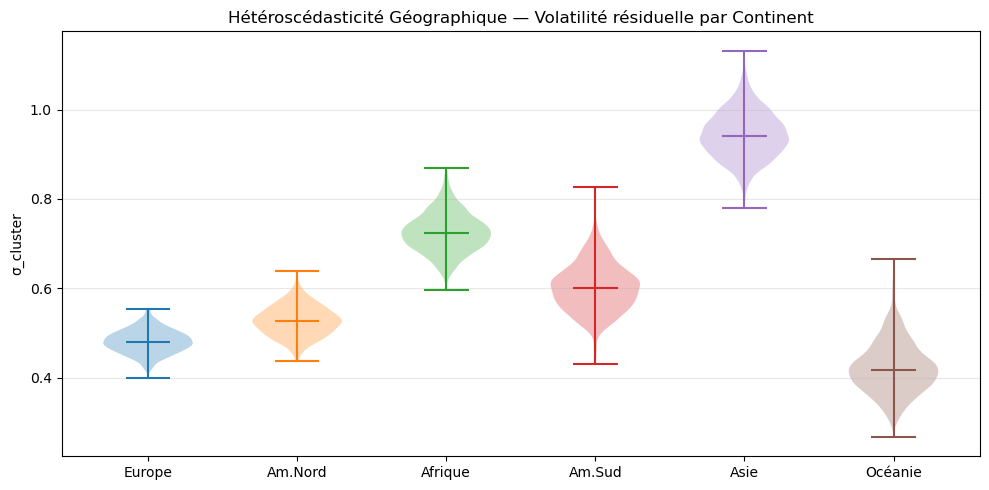

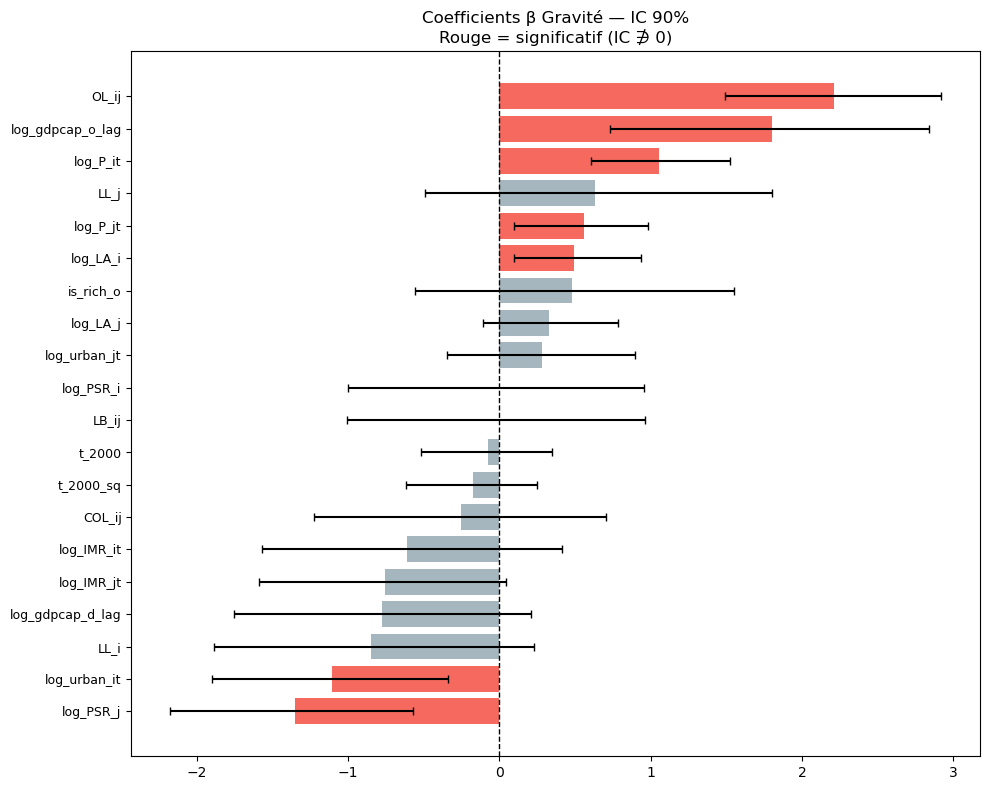

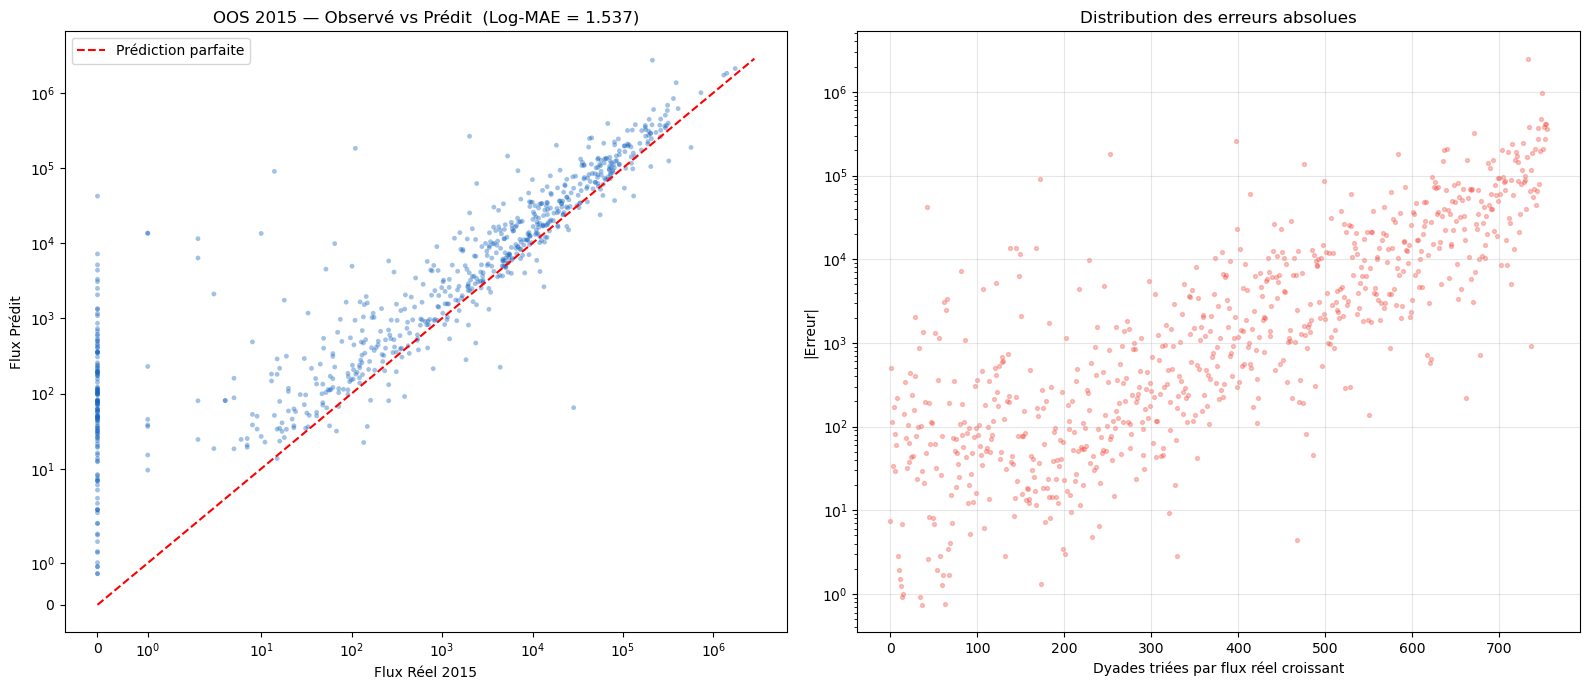

In [ ]:
# Visualisations




CONTINENT_NAMES = {1:'Europe', 2:'Am.Nord', 3:'Afrique',
                   4:'Am.Sud', 5:'Asie', 6:'Océanie'}

fig, ax = plt.subplots(figsize=(10, 5))
sigma_draws = idata.posterior['sigma_cluster'].values  
for k in range(1, K_clusters + 1):
    draws_k = sigma_draws[..., k-1].flatten()
    ax.violinplot(draws_k, positions=[k], widths=0.6, showmedians=True)
ax.set_xticks(range(1, K_clusters + 1))
ax.set_xticklabels([CONTINENT_NAMES.get(k, f'C{k}') for k in range(1, K_clusters + 1)])
ax.set_ylabel("σ_cluster")
ax.set_title("Hétéroscédasticité Géographique — Volatilité résiduelle par Continent")
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('variance_cluster.pdf', bbox_inches='tight')
plt.show()

beta_flat  = idata.posterior['beta_grav'].values.reshape(-1, K_grav)
beta_means = beta_flat.mean(axis=0)
beta_q05, beta_q95 = np.percentile(beta_flat, [5, 95], axis=0)
order = np.argsort(beta_means)

fig, ax = plt.subplots(figsize=(10, max(6, K_grav * 0.4)))
colors_coef = ['#F44336' if beta_q05[i] > 0 or beta_q95[i] < 0
               else '#90A4AE' for i in order]
ax.barh(range(K_grav), beta_means[order],
        xerr=[beta_means[order] - beta_q05[order],
              beta_q95[order]   - beta_means[order]],
        color=colors_coef, alpha=0.8, capsize=3)
ax.set_yticks(range(K_grav))
ax.set_yticklabels([X_VOL_COLS[i] for i in order], fontsize=9)
ax.axvline(0, color='black', lw=1, ls='--')
ax.set_title("Coefficients β Gravité — IC 90%\nRouge = significatif (IC ∌ 0)")
plt.tight_layout()
plt.savefig('gravity_coefficients.pdf', bbox_inches='tight') # ne pas enlever les variables non significatives. Elles pourraient le devenir pour 190 pays, c'est ce qu'on attend. 
plt.show()     # avec 190 pays, le modèle sera largement assez puissant pour detecter tous les effets. Sauf peut être les variables englobées par d'autres (par ex LB_ij capturé par le Hurdle et par D_ij)

# Variables politiques et de conflit à ajouter:                                                      
# UCDP/PRIO Armed Conflict Dataset
# Freedom House / Polity V
# Aucune modification dans Stan (K_v est déjà paramétrique) , juste merge puis 2 lignes Python. 
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
ax.scatter(y_true, y_pred, alpha=0.4, s=12, color='#1565C0', edgecolors='none')
lim = [0, max(y_true.max(), y_pred.max()) * 1.05]
ax.plot(lim, lim, 'r--', lw=1.5, label='Prédiction parfaite')
ax.set_xscale('symlog')
ax.set_yscale('symlog')
ax.set_xlabel("Flux Réel 2015")
ax.set_ylabel("Flux Prédit")
ax.set_title(f"OOS 2015 — Observé vs Prédit  (Log-MAE = {log_mae:.3f})")
ax.legend()

ax2 = axes[1]
order_err = np.argsort(y_true)
ax2.scatter(range(len(y_true)), np.abs(y_true[order_err] - y_pred[order_err]),
            alpha=0.3, s=8, color='#F44336')
ax2.set_xlabel("Dyades triées par flux réel croissant")
ax2.set_ylabel("|Erreur|")
ax2.set_yscale('log')
ax2.set_title("Distribution des erreurs absolues")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_scatter.pdf', bbox_inches='tight')
plt.show()

In [ ]:
summary = fit.summary()

# Hyperparamètres globaux uniquement (lisible)
params_watch = [
    'alpha_global', 'tau_alpha', 'beta_lag_global',
    'mu_intercept', 'tau_mu', 'phi_global_monitor',
    'sigma_global', 'tau_sigma', 'tau_phi',
    'sigma_cluster[1]', 'sigma_cluster[2]', 'sigma_cluster[3]',
    'sigma_cluster[4]', 'sigma_cluster[5]', 'sigma_cluster[6]',
]

# Filtre sur les params qui existent vraiment dans le summary
params_found = [p for p in params_watch if p in summary.index]
print(summary.loc[params_found, ['Mean', 'StdDev', '5%', '95%', 'R_hat', 'ESS_bulk']])

print(f"\nR_hat max (tous paramètres) : {summary['R_hat'].max():.4f}")
print(f"ESS_bulk min               : {summary['ESS_bulk'].min():.0f}")
print(f"Nb divergences             : {fit.divergences.sum()}")


In [ ]:
beta_draws = fit.stan_variable('beta_grav')  # (n_draws, K_grav)
beta_means = beta_draws.mean(axis=0)
beta_q05   = np.percentile(beta_draws, 5,  axis=0)
beta_q95   = np.percentile(beta_draws, 95, axis=0)

print(f"{'Variable':<25} {'Moyenne':>10} {'IC 5%':>10} {'IC 95%':>10}  {'Significatif?':>14}")
print("-" * 65)
for j, col in enumerate(X_VOL_COLS):
    sig = "✓ OUI" if (beta_q05[j] > 0 or beta_q95[j] < 0) else "  non"
    print(f"{col:<25} {beta_means[j]:>10.3f} {beta_q05[j]:>10.3f} {beta_q95[j]:>10.3f}  {sig:>14}")

Figure 1: le Graal, ce serait des formes étalées horizontalement, basses sur l'axe des Y (modèle sûr de lui + volatilité basse). 
Figure 2: 